# 02 · Modeling, Grid Search & SHAP

Tunes Logistic Regression, Random Forest, and KNN per era by **grid search (cross-validation)**, compares them, and explains the best model (Random Forest) with **SHAP** — then compares feature importance across eras.

In [1]:
import pandas as pd, json
from IPython.display import Image, display
pd.set_option('display.precision', 3)
ERAS = ['Analog (1960-89)','CD/Digital (1990-2009)','Streaming (2010s)']
g   = pd.read_csv('../results/grid_final.csv')
sh  = pd.read_csv('../results/shap_meanabs_tuned.csv')
print(len(g),'tuned (era x model) results loaded')

9 tuned (era x model) results loaded


## Hyperparameter tuning — settings chosen by grid search
The parameters are now data-driven (not hand-picked), which answers the 'why these settings?' question.

In [2]:
bp = g.assign(hp=g['best_params'].apply(lambda s: ', '.join(f'{k.replace("m__","")}={v}' for k,v in json.loads(s).items())))
display(bp[['group','model','hp','roc_auc_mean']].rename(columns={'group':'era','hp':'best_hyperparameters','roc_auc_mean':'ROC_AUC'}))

,era,model,best_hyperparameters,ROC_AUC
0,Analog (1960-89),LogReg,"C=1, penalty=l1",0.786
1,Analog (1960-89),RandomForest,"max_depth=20, n_estimators=300",0.848
2,Analog (1960-89),KNN,"n_neighbors=75, weights=distance",0.810
3,CD/Digital (1990-2009),LogReg,"C=100, penalty=l2",0.874
4,CD/Digital (1990-2009),RandomForest,"max_depth=20, n_estimators=300",0.917
5,CD/Digital (1990-2009),KNN,"n_neighbors=45, weights=distance",0.889
6,Streaming (2010s),LogReg,"C=100, penalty=l2",0.864
7,Streaming (2010s),RandomForest,"max_depth=20, n_estimators=300",0.912
8,Streaming (2010s),KNN,"n_neighbors=75, weights=distance",0.863


## Classifier performance by era
Random Forest wins in every era; predictability also rises over time.

,Logistic Reg.,KNN,Random Forest
group,,,
Analog (1960-89),0.786,0.810,0.848
CD/Digital (1990-2009),0.874,0.889,0.917
Streaming (2010s),0.864,0.863,0.912


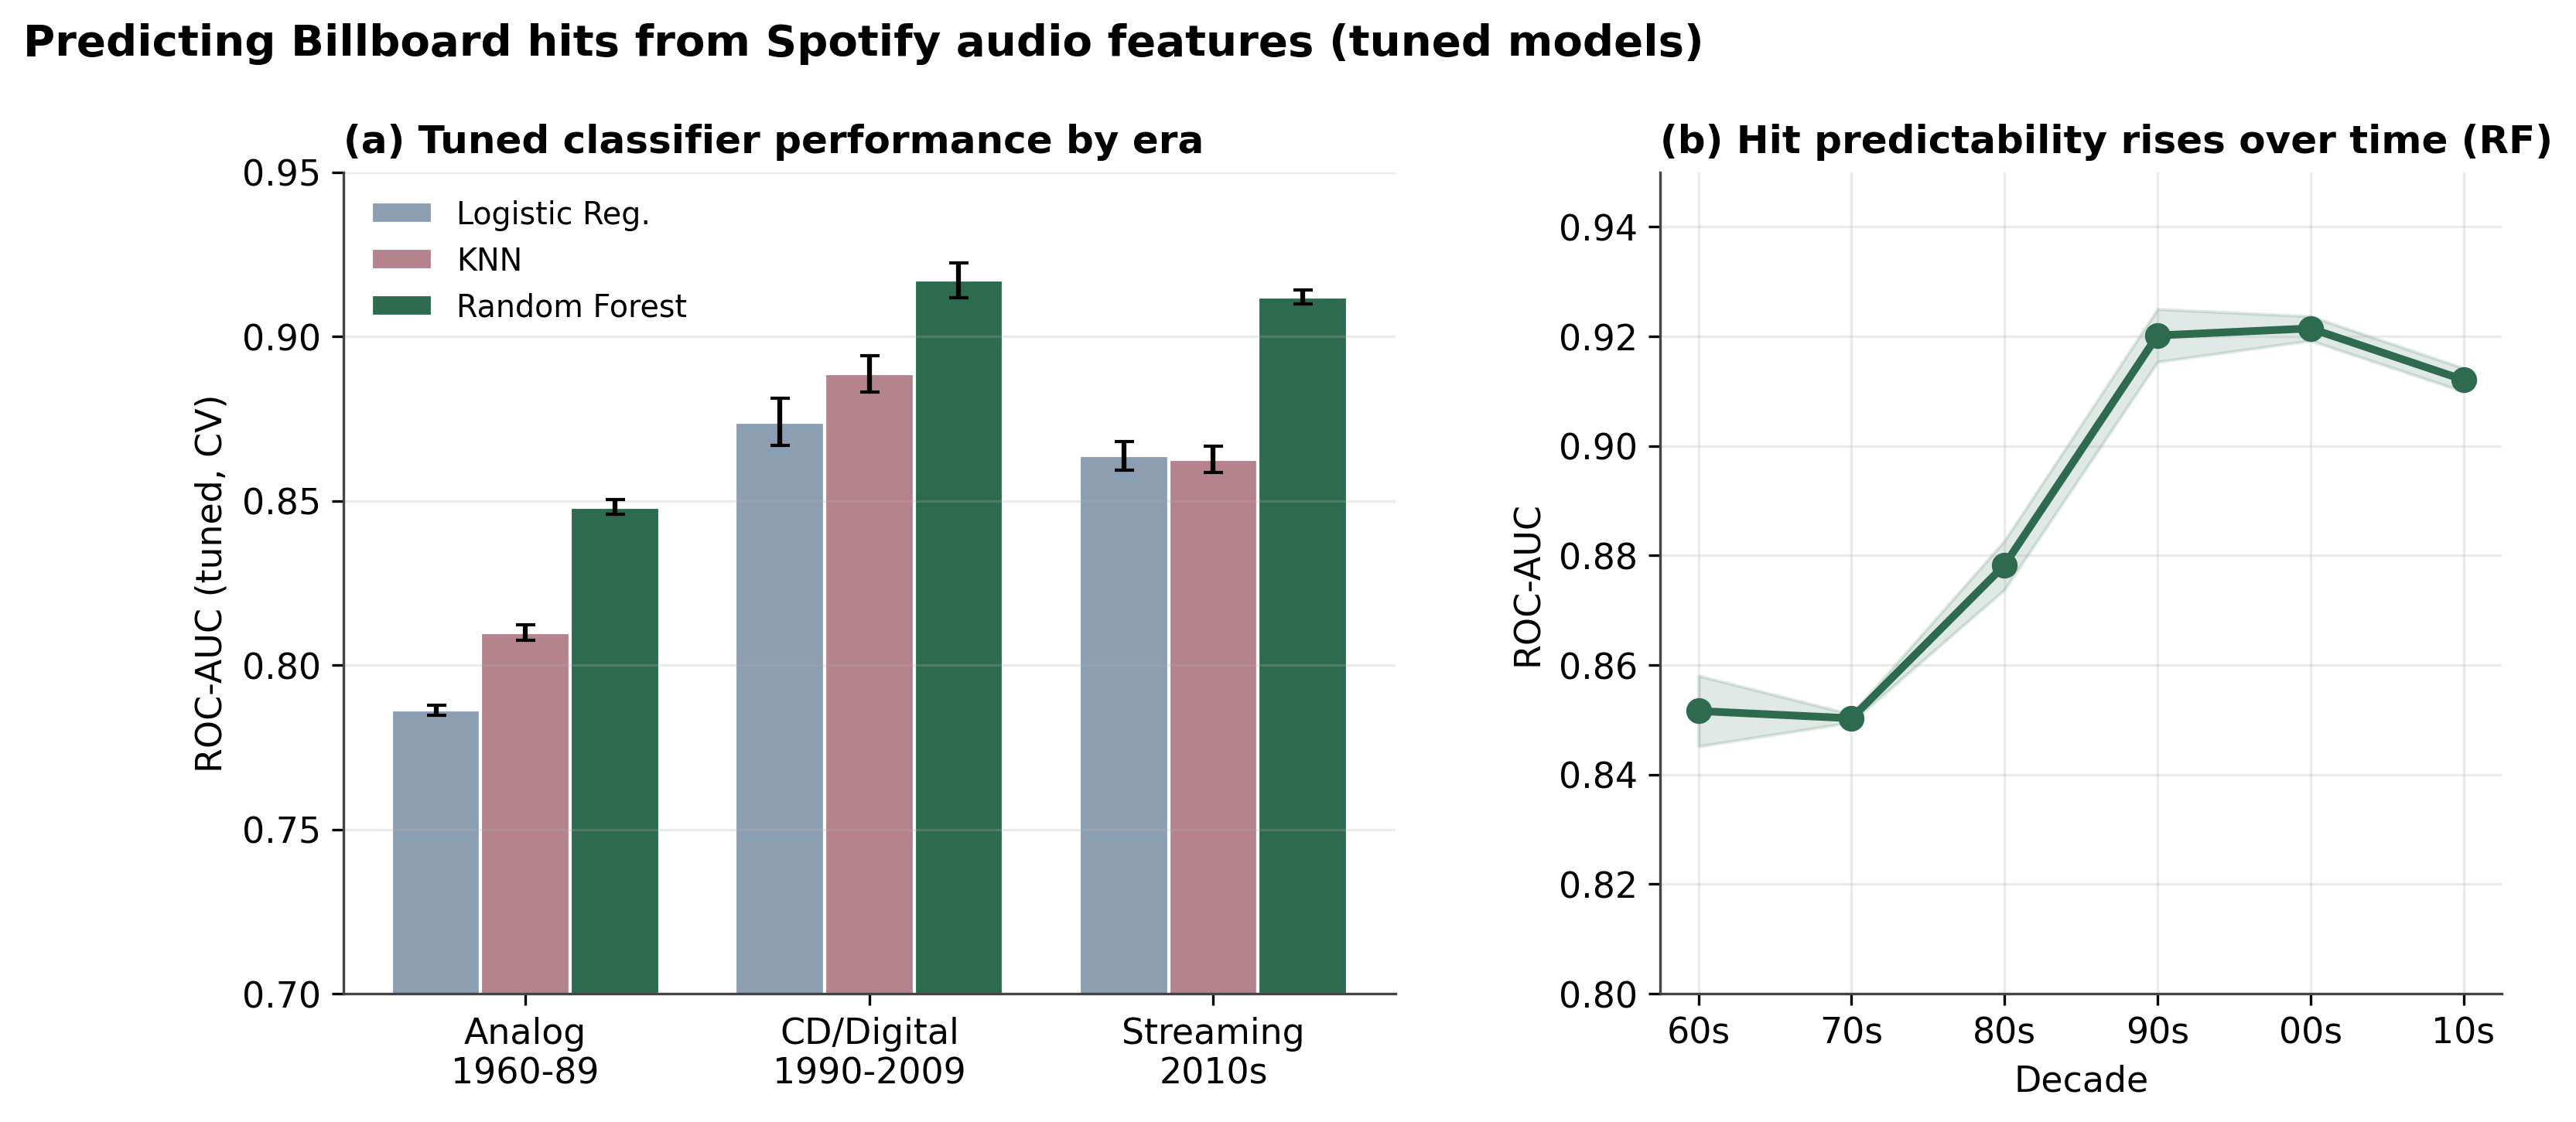

In [3]:
perf = g.pivot(index='group', columns='model', values='roc_auc_mean').reindex(ERAS)[['LogReg','KNN','RandomForest']]
perf.columns=['Logistic Reg.','KNN','Random Forest']
display(perf)
display(Image('../figures/fig1_model_performance.png'))

## Feature importance by era (SHAP)
`instrumentalness` is #1 in every era and rising; `loudness` climbs to #2 by the streaming era.

group,Analog (1960-89),CD/Digital (1990-2009),Streaming (2010s)
feature,,,
instrumentalness,0.095,0.113,0.169
acousticness,0.056,0.065,0.047
speechiness,0.051,0.025,0.009
danceability,0.047,0.090,0.059
loudness,0.030,0.038,0.063
energy,0.029,0.027,0.042
valence,0.025,0.015,0.020
duration_ms,0.019,0.065,0.031
mode,0.018,0.004,0.001


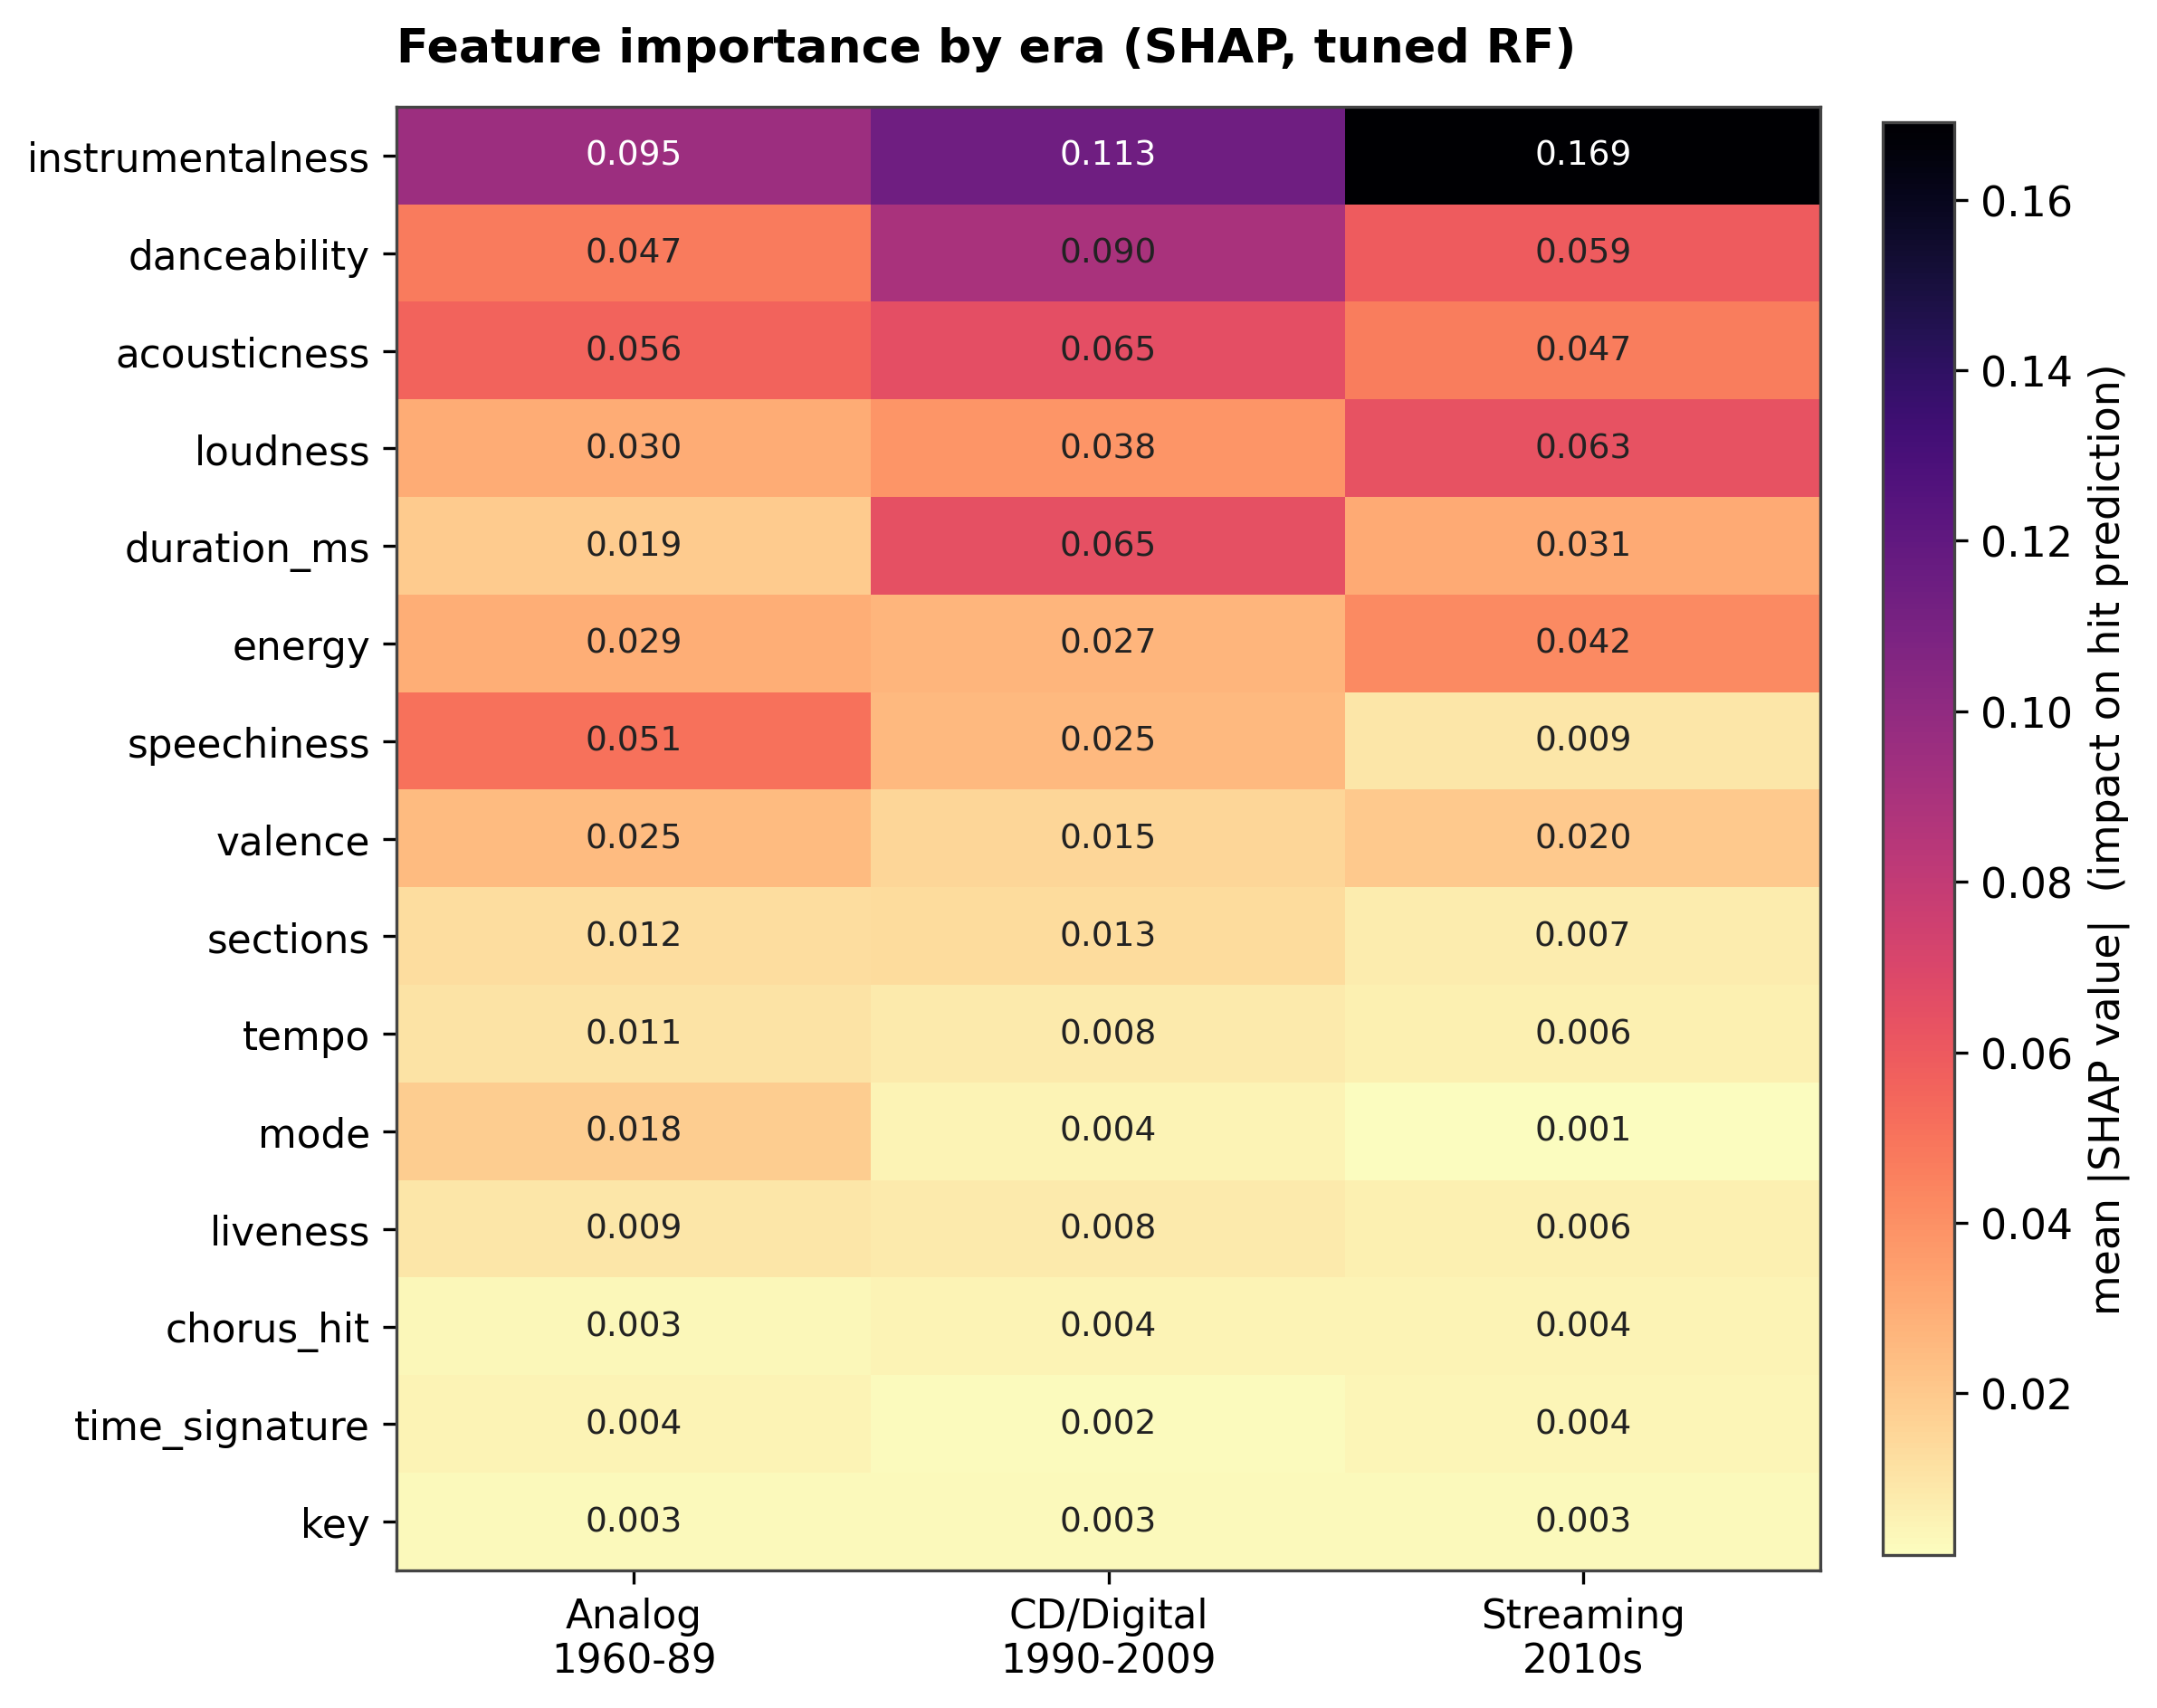

In [4]:
piv = sh[sh.level=='era'].pivot(index='feature', columns='group', values='mean_abs_shap')[ERAS]
display(piv.sort_values(ERAS[0], ascending=False))
display(Image('../figures/fig2_shap_heatmap_era.png'))

## Trend across decades

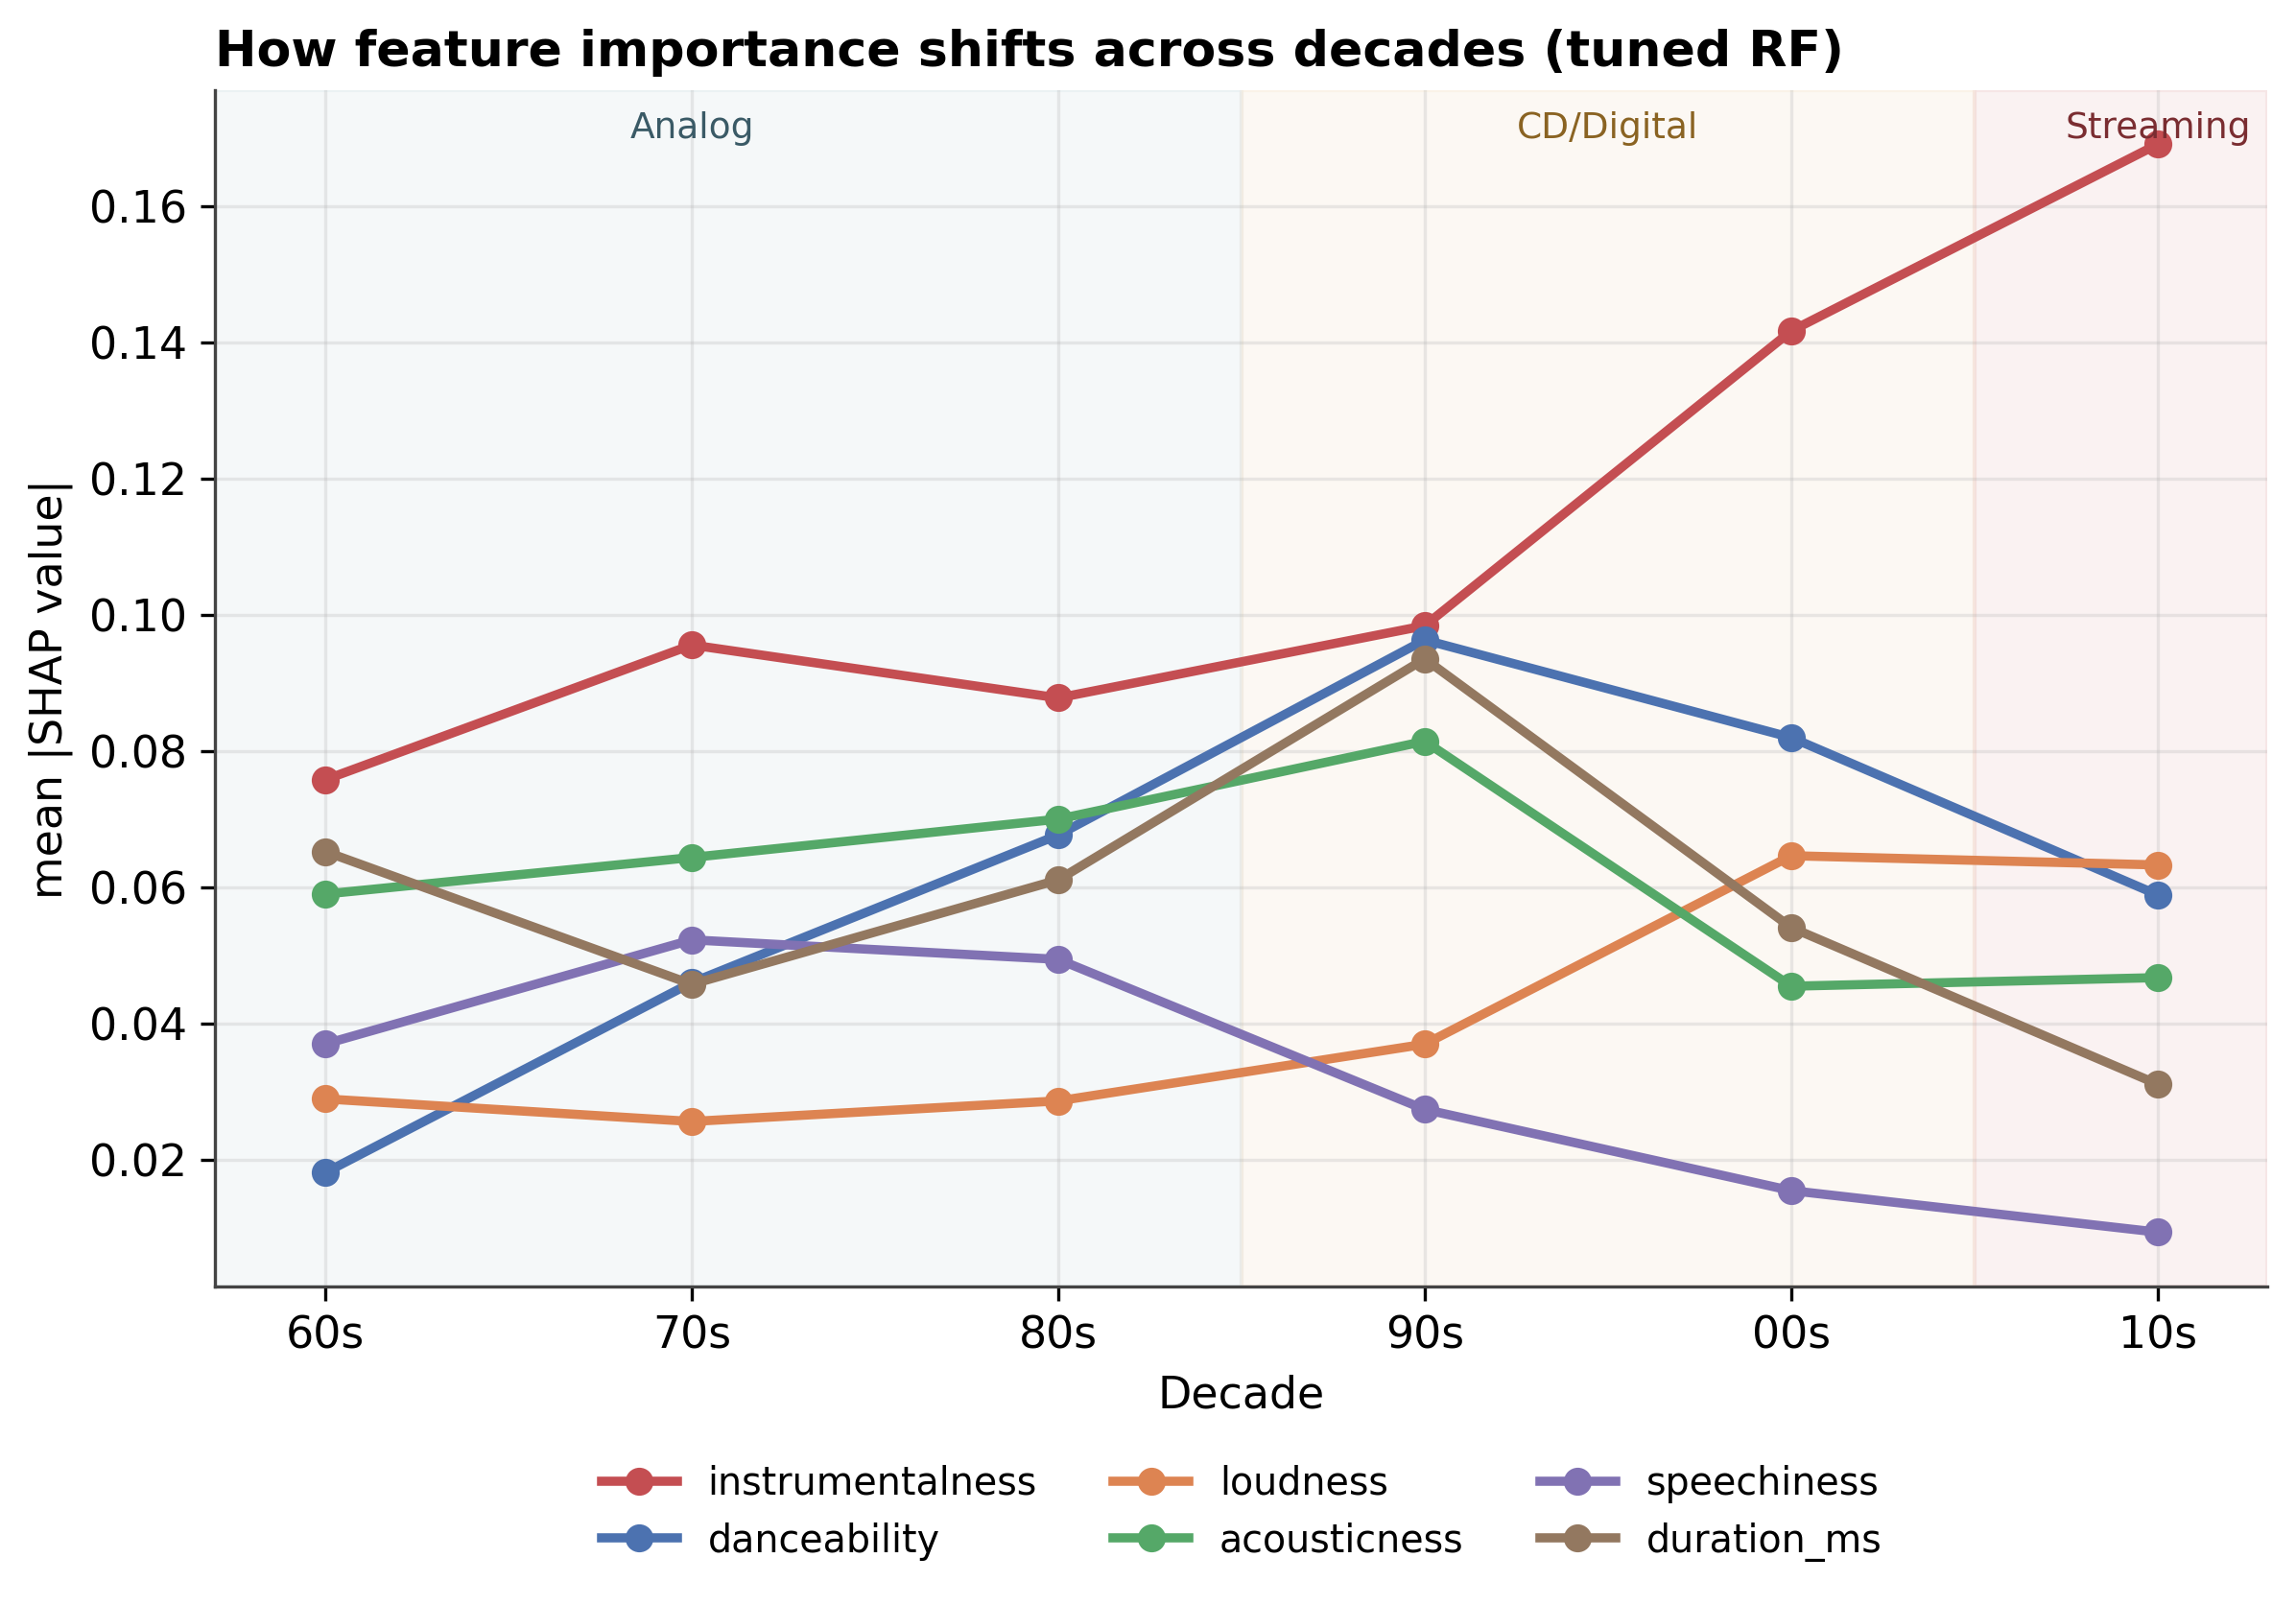

In [5]:
display(Image('../figures/fig3_shap_trend_decade.png'))

## Direction of effect (Logistic-Regression coefficients)

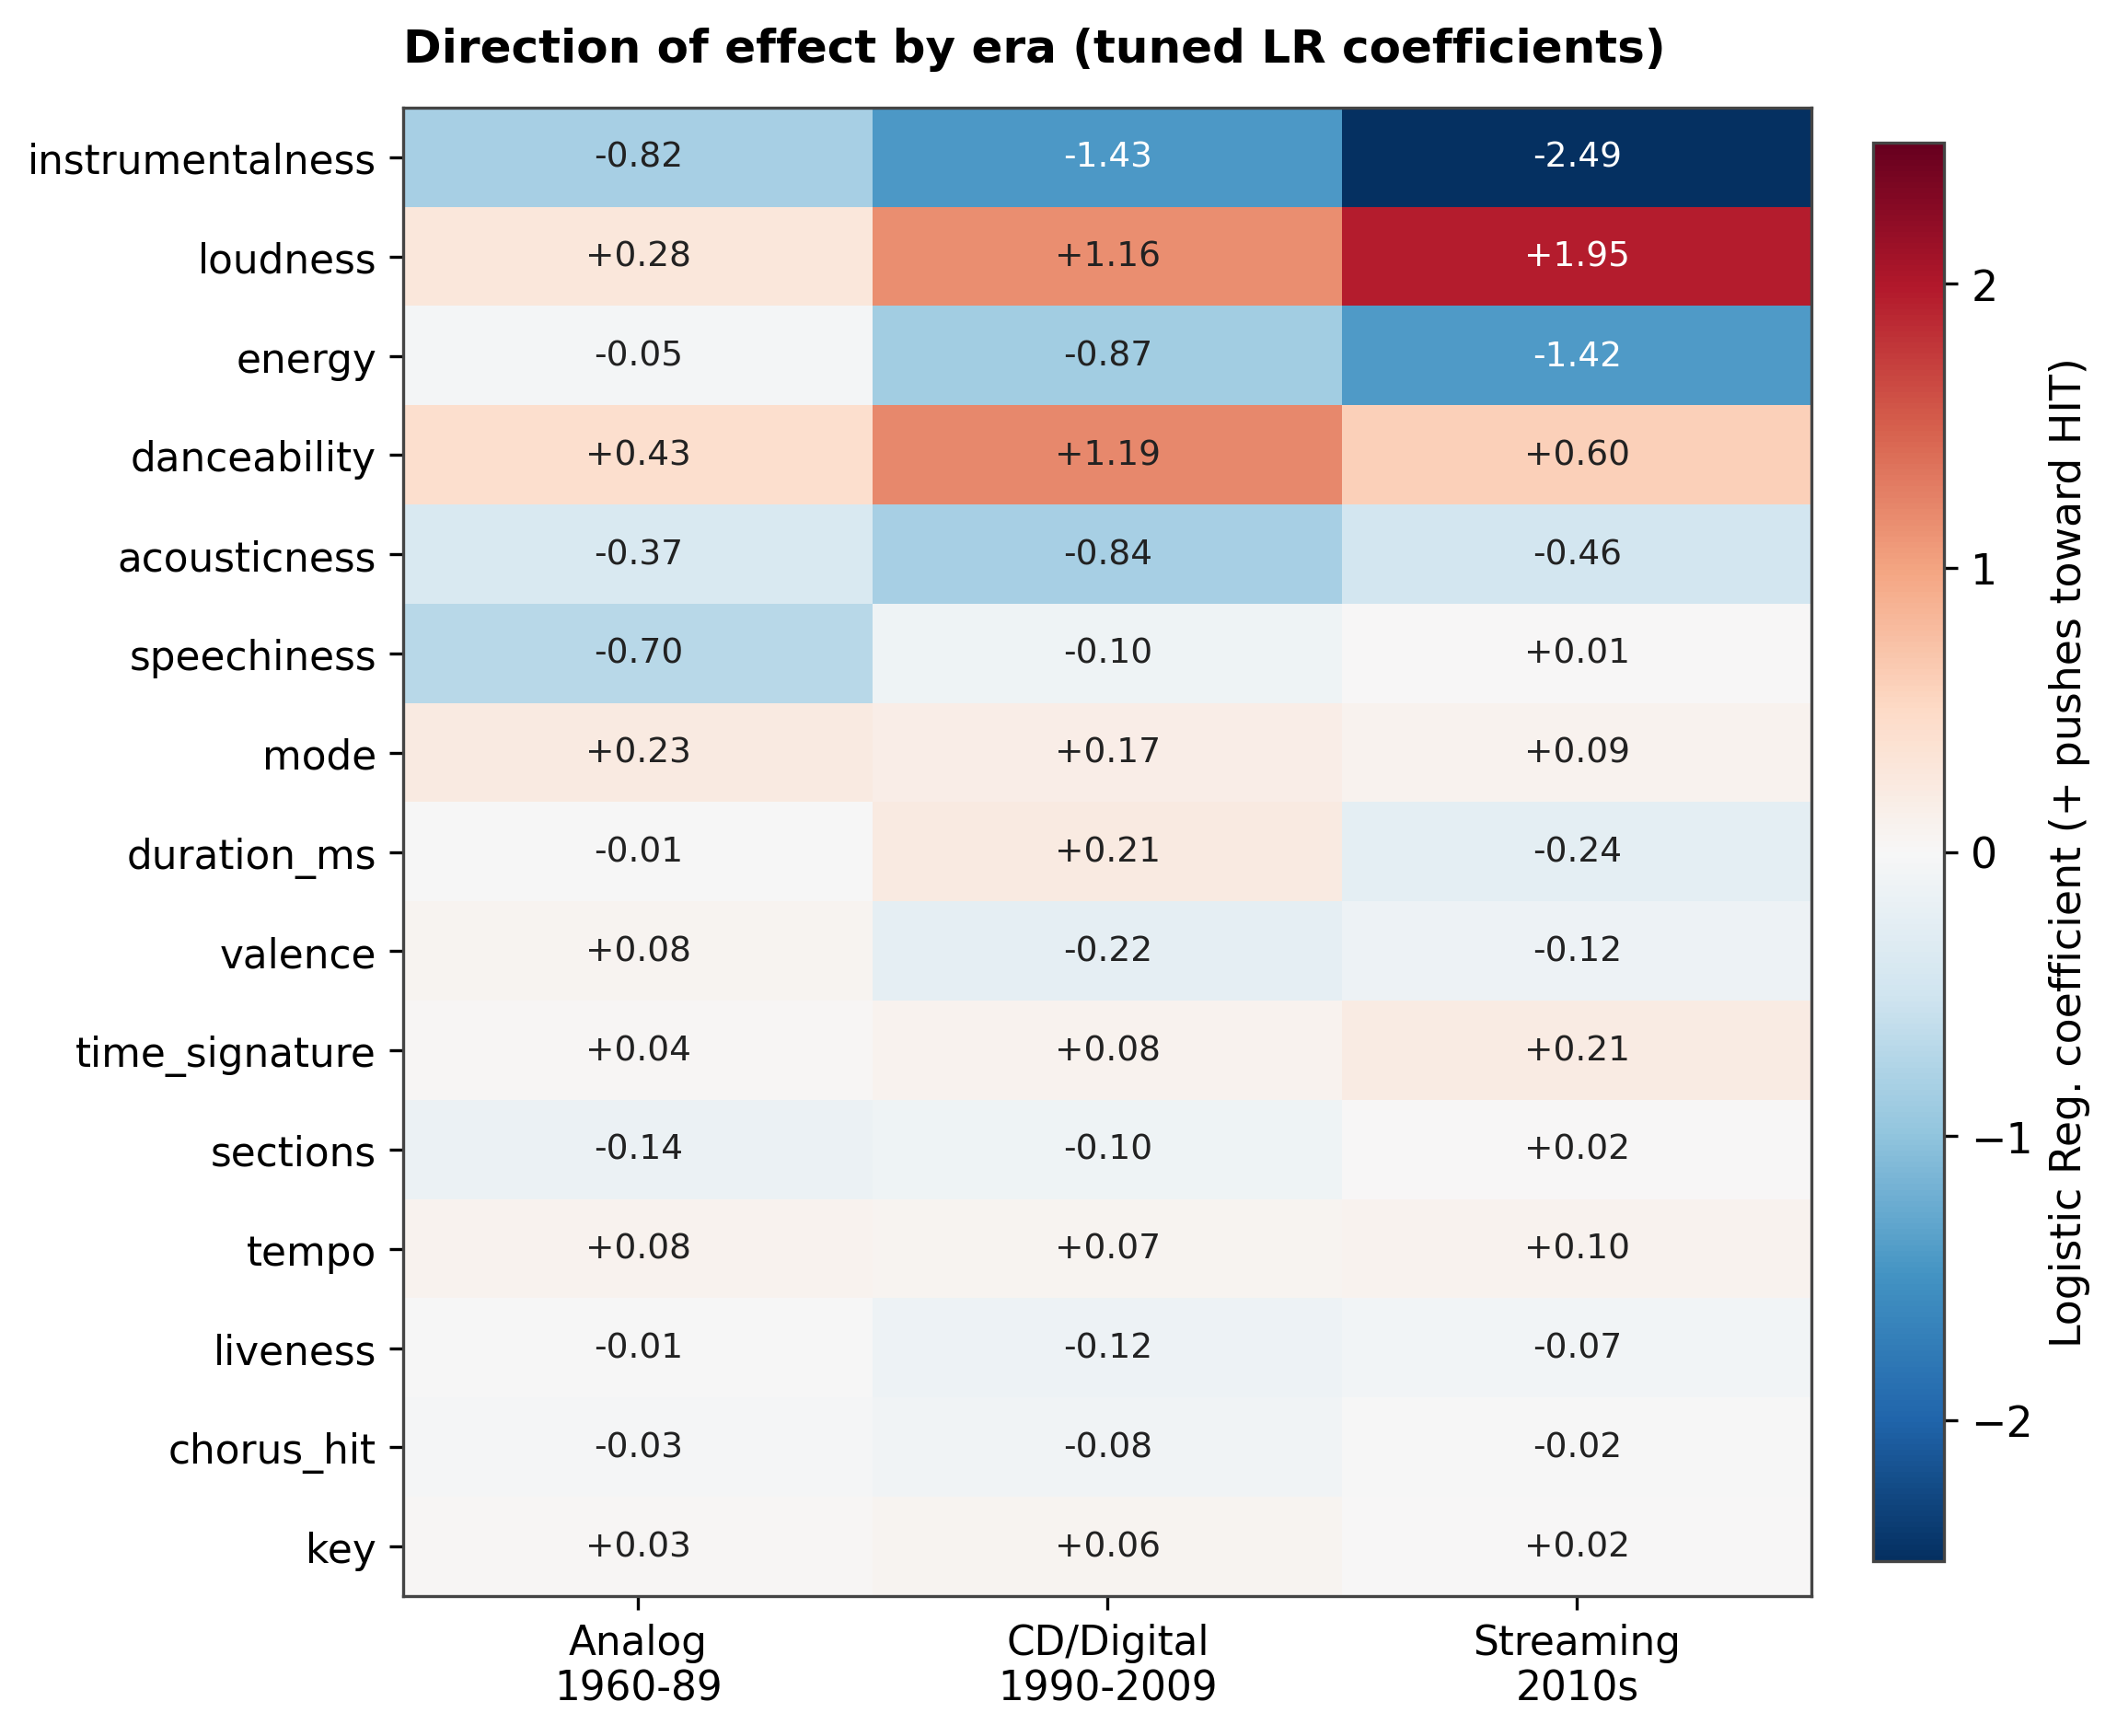

In [6]:
display(Image('../figures/fig4_lr_direction_era.png'))

## SHAP beeswarms by era

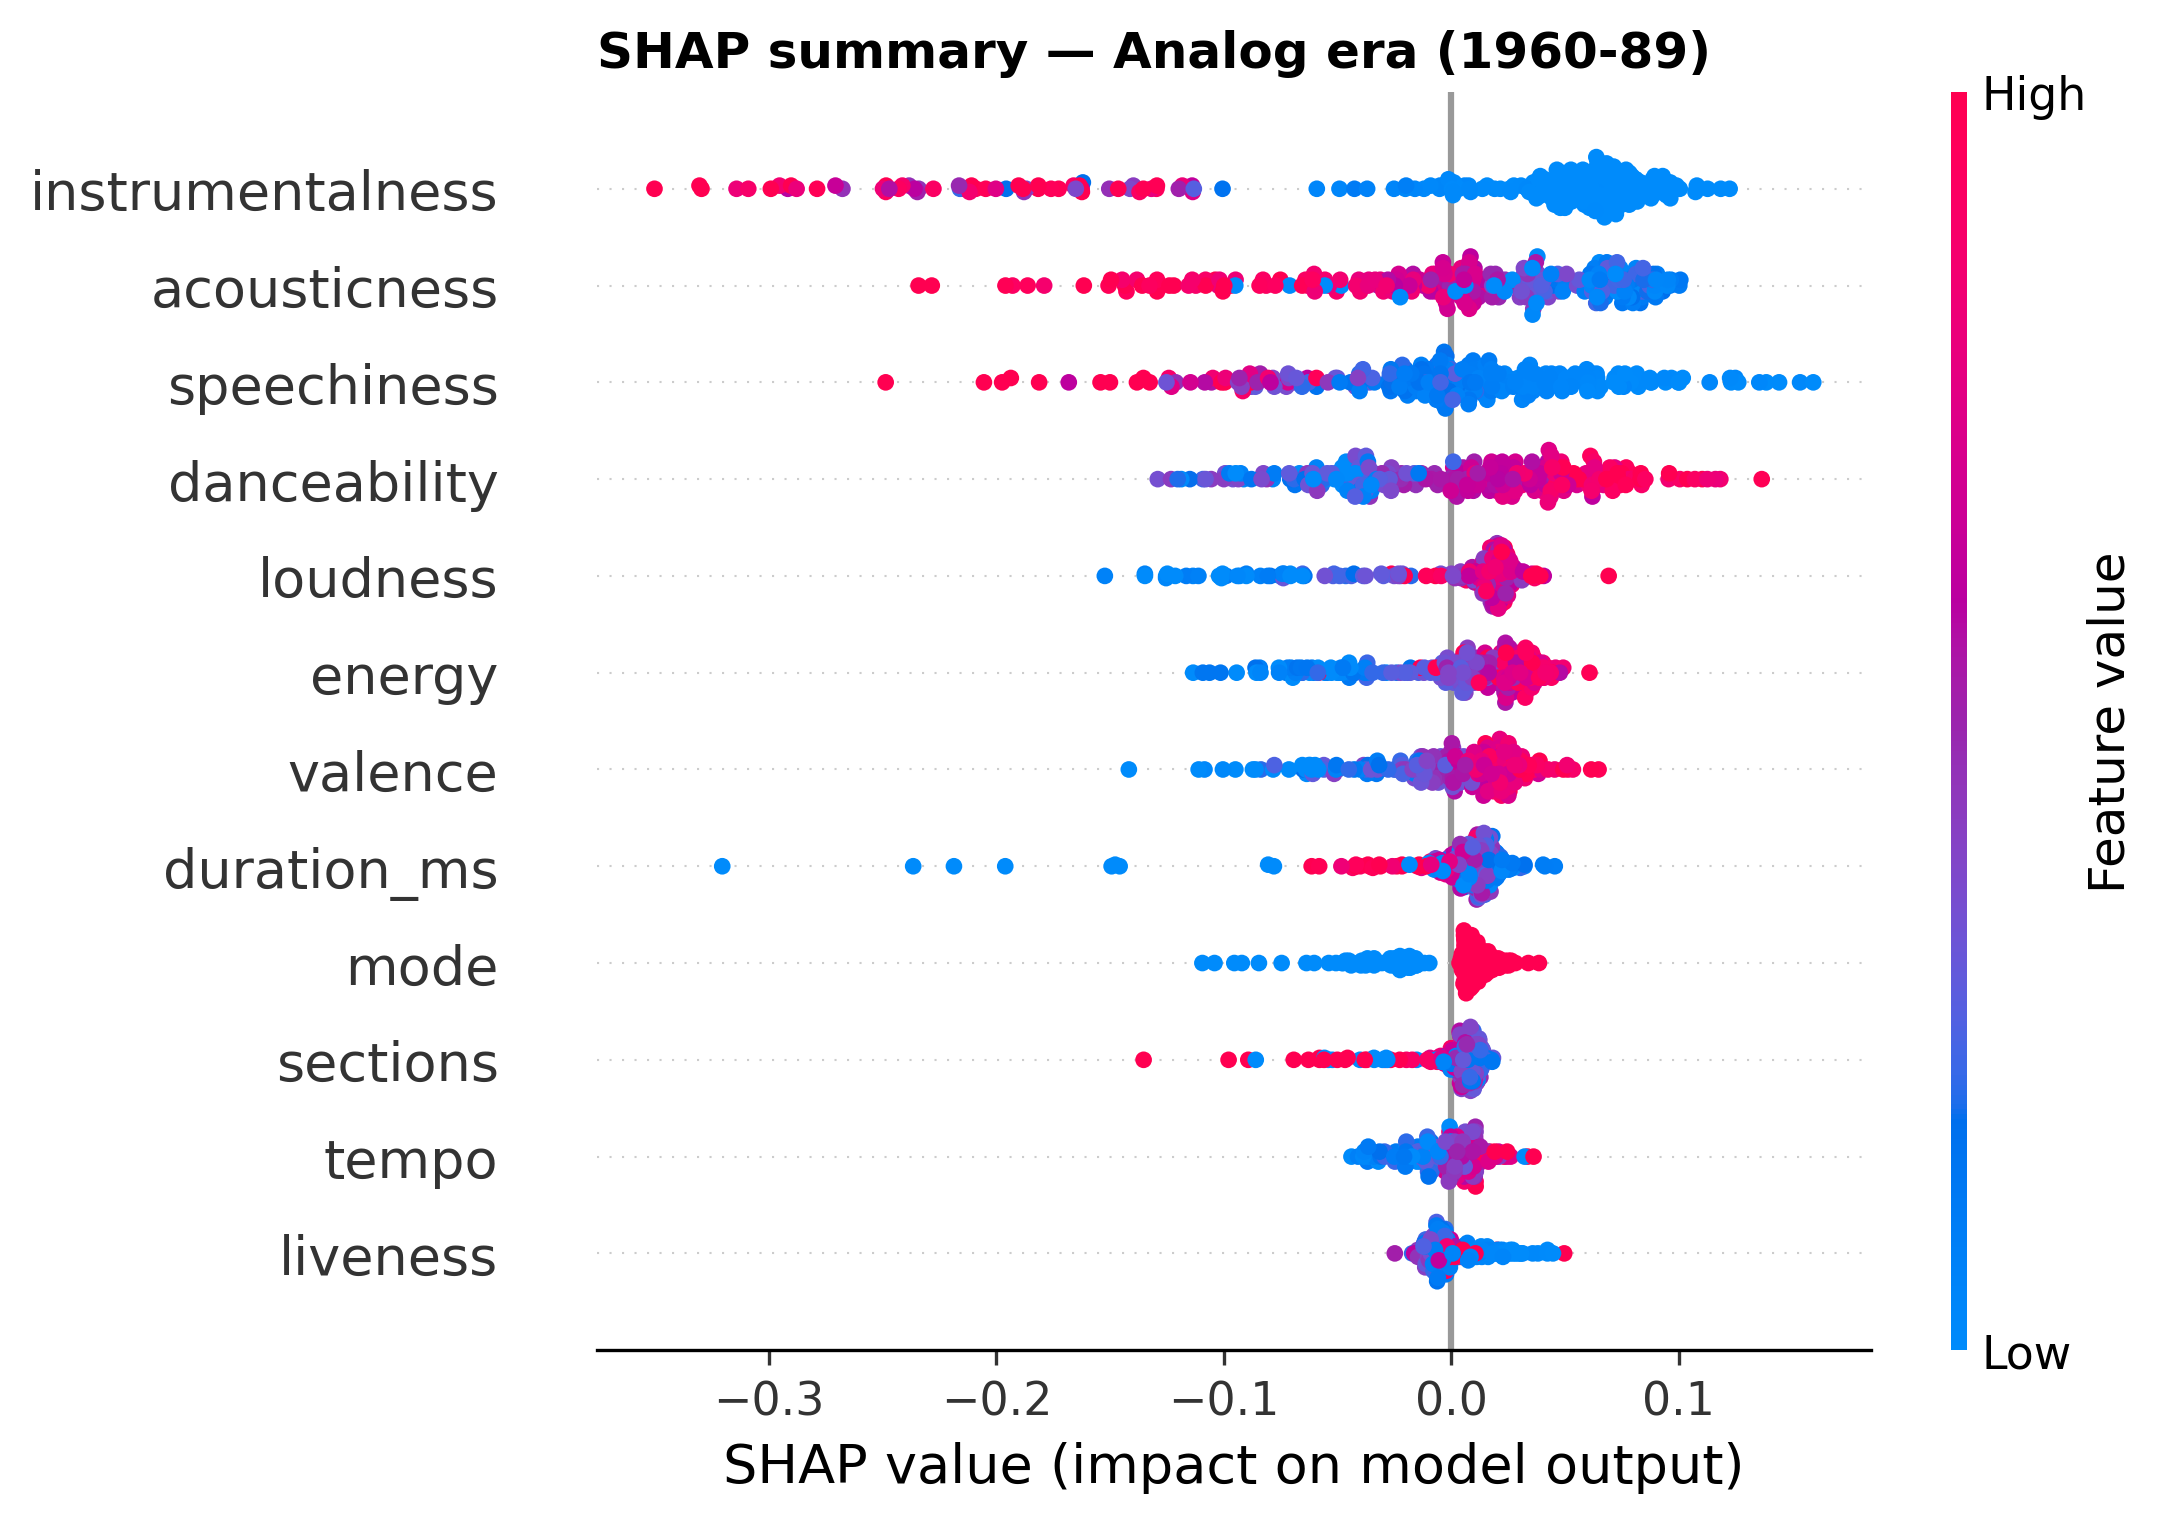

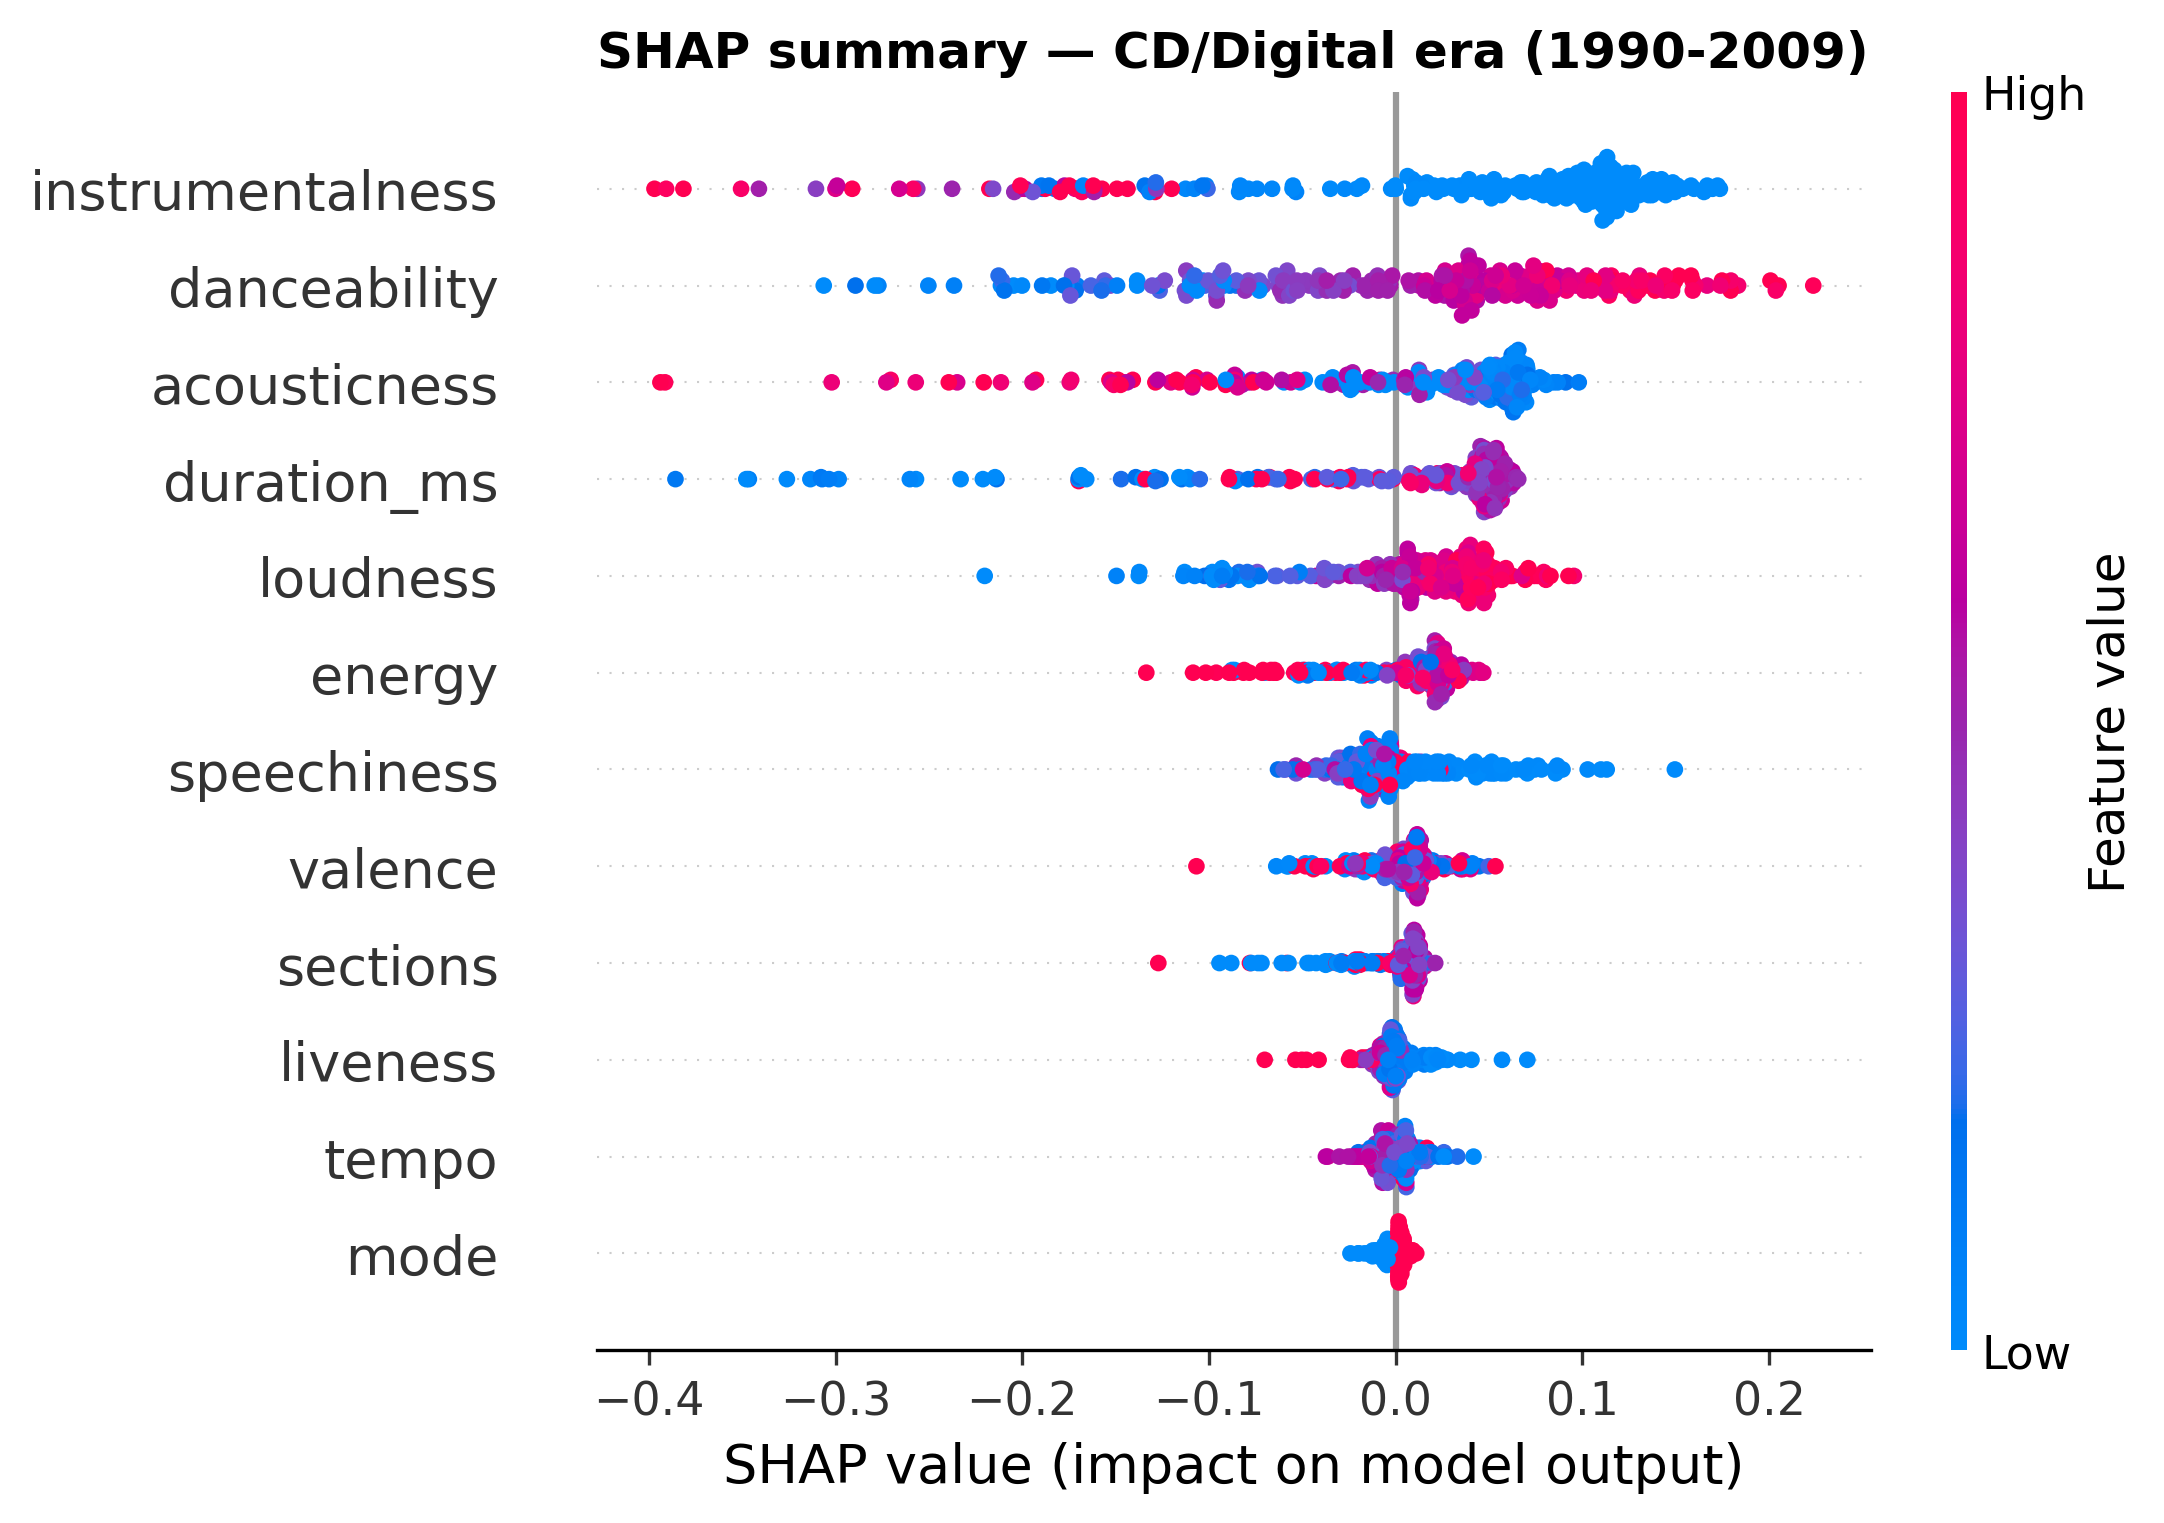

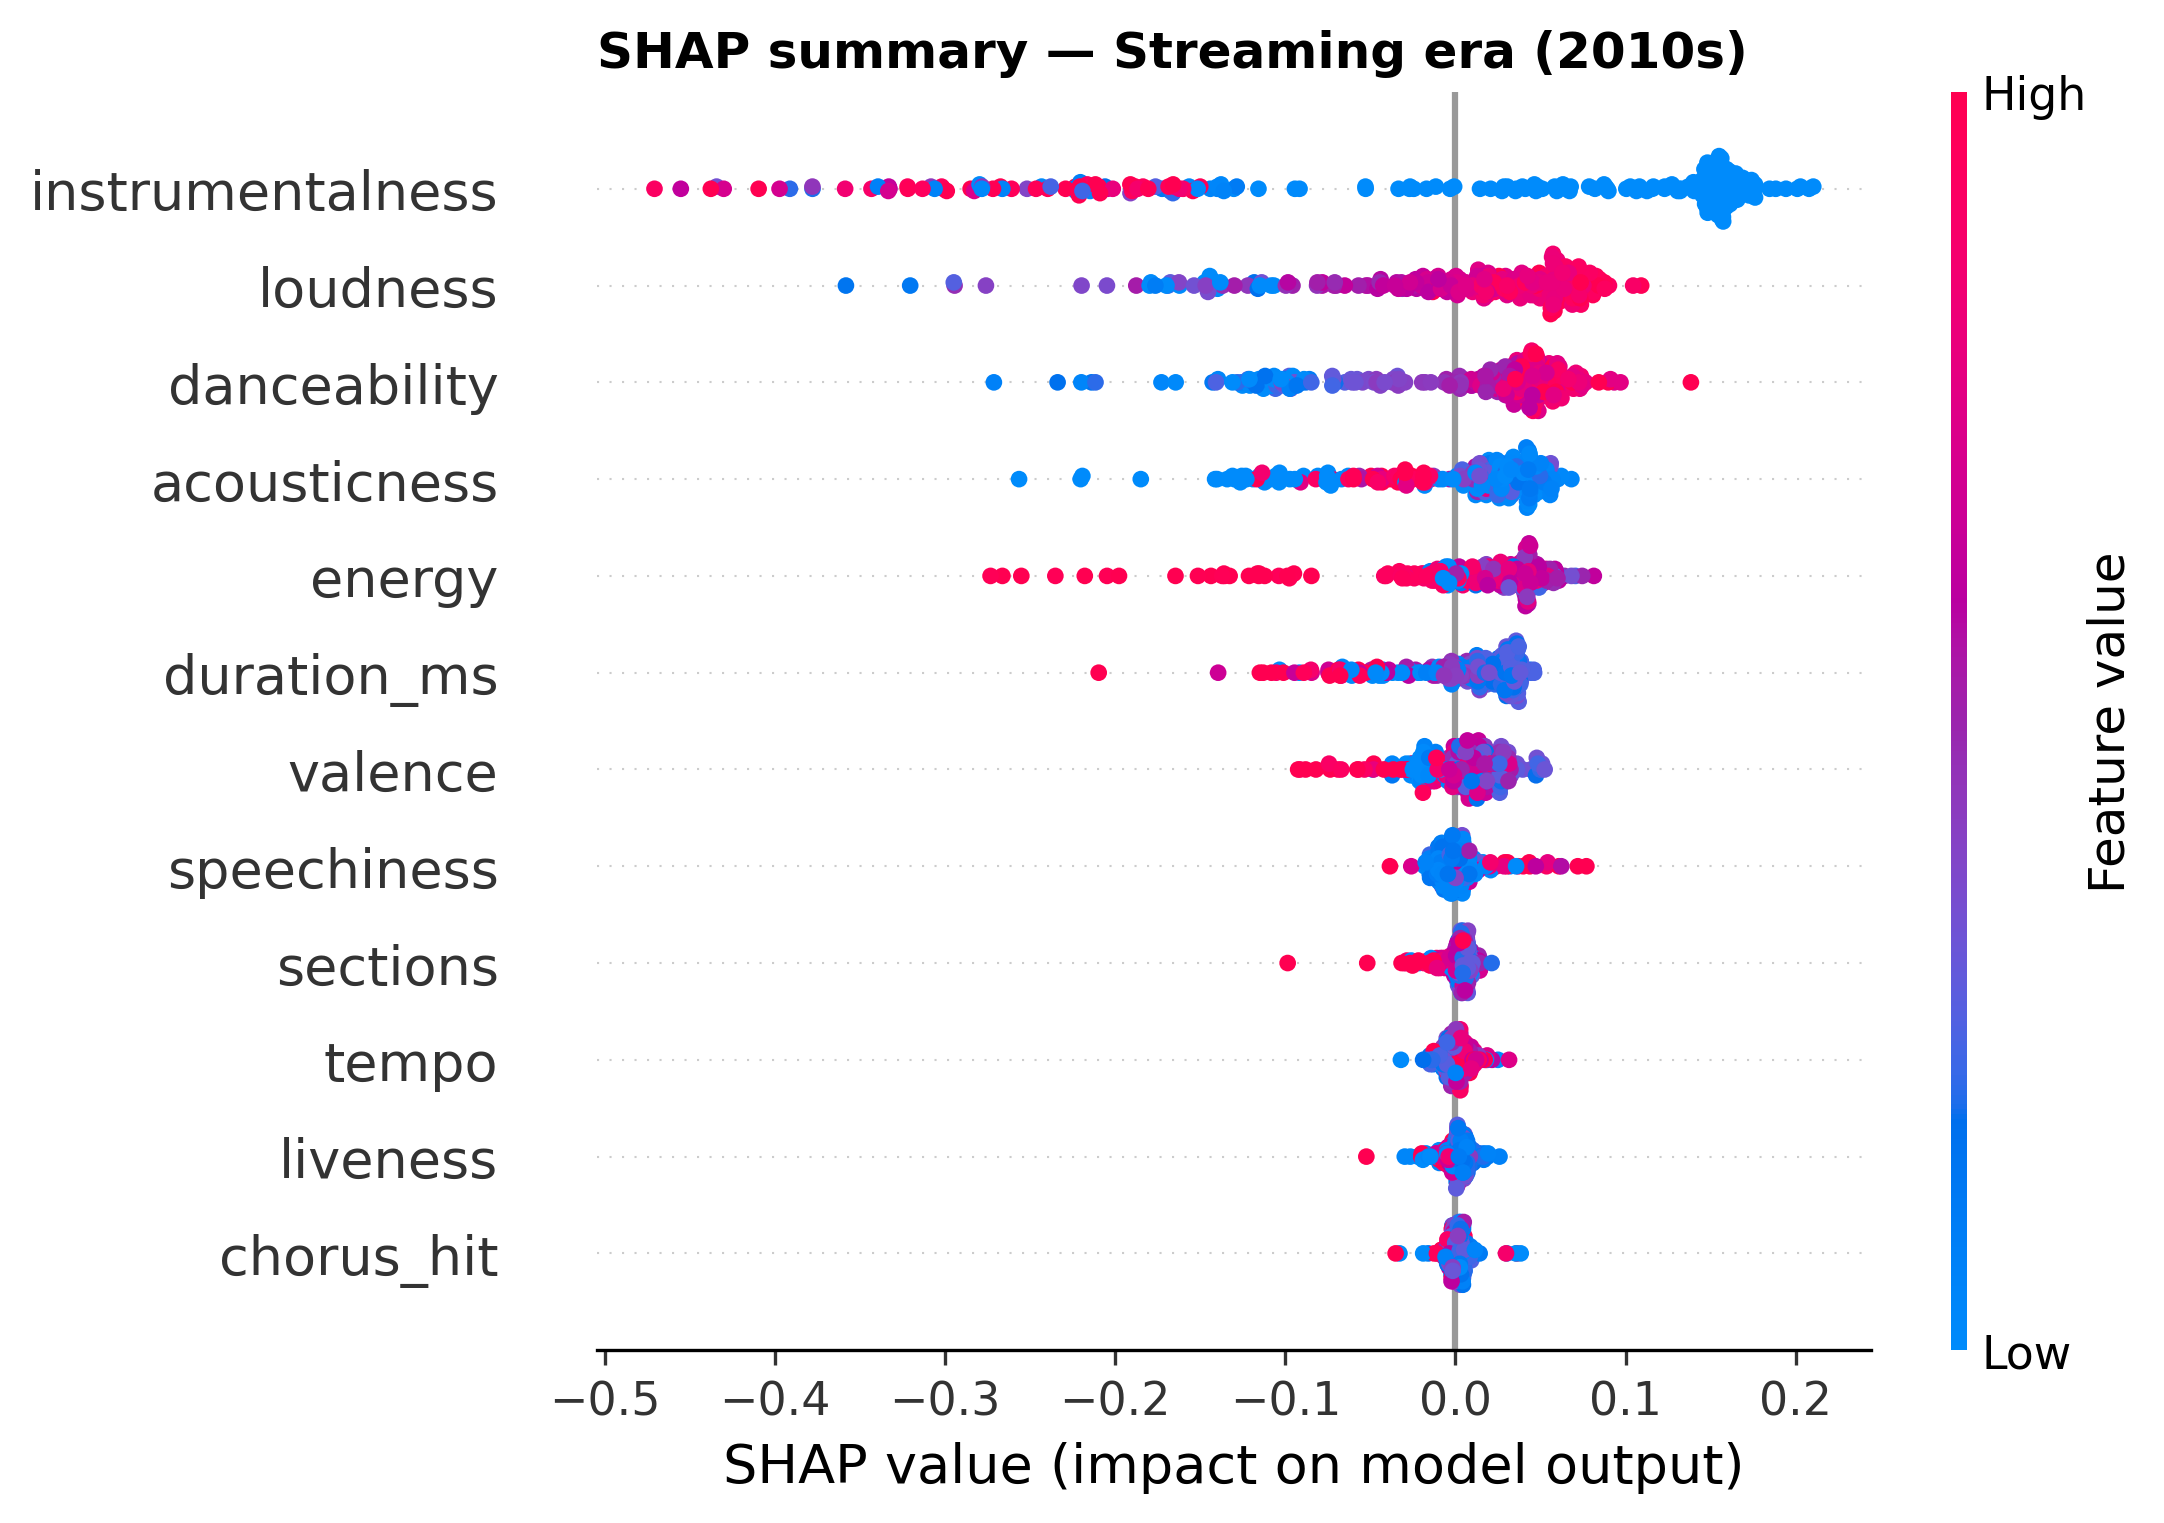

In [7]:
for f in ['../figures/fig5_beeswarm_Analog.png','../figures/fig5_beeswarm_CD_Digital.png','../figures/fig5_beeswarm_Streaming.png']:
    display(Image(f))

## Reproduce
Run the full pipeline (EDA → grid search → tuned SHAP → figures):
```bash
python ../spotify_hit_analysis.py
```